In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn import metrics

import warnings
warnings.filterwarnings('ignore')

In [154]:
df = pd.read_csv(r'C:\Users\jolla\OneDrive\Documents\python class\MSFT5YRHISTORICAL.csv')
df.head()

,Date,Close,Open,High,Low,Volume
0,5/2/2025,435.28,431.74,439.44,429.99,30757430
1,5/1/2025,425.40,431.11,436.99,424.90,58938100
2,4/30/2025,395.26,390.30,396.66,384.44,36461080
3,4/29/2025,394.04,391.30,395.10,390.38,14973980
4,4/28/2025,391.16,391.96,392.74,386.64,16579430


In [155]:
df.shape

(1257, 6)

In [156]:
df.describe()

,Close,Open,High,Low,Volume
count,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03
mean,309.962649,309.862315,312.902418,306.723612,2.703850e+07
std,76.494461,76.530817,76.840377,76.044728,1.043966e+07
min,178.840000,174.490000,179.000000,173.800000,7.164543e+06
25%,245.420000,245.030000,247.990000,242.950000,2.006594e+07
50%,296.770000,296.660000,299.970000,293.920000,2.479183e+07
75%,382.140000,379.780000,385.220000,376.910000,3.120249e+07
max,467.560000,467.000000,468.350000,464.460000,9.042885e+07


In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1257 non-null   object 
 1   Close   1257 non-null   float64
 2   Open    1257 non-null   float64
 3   High    1257 non-null   float64
 4   Low     1257 non-null   float64
 5   Volume  1257 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 59.1+ KB


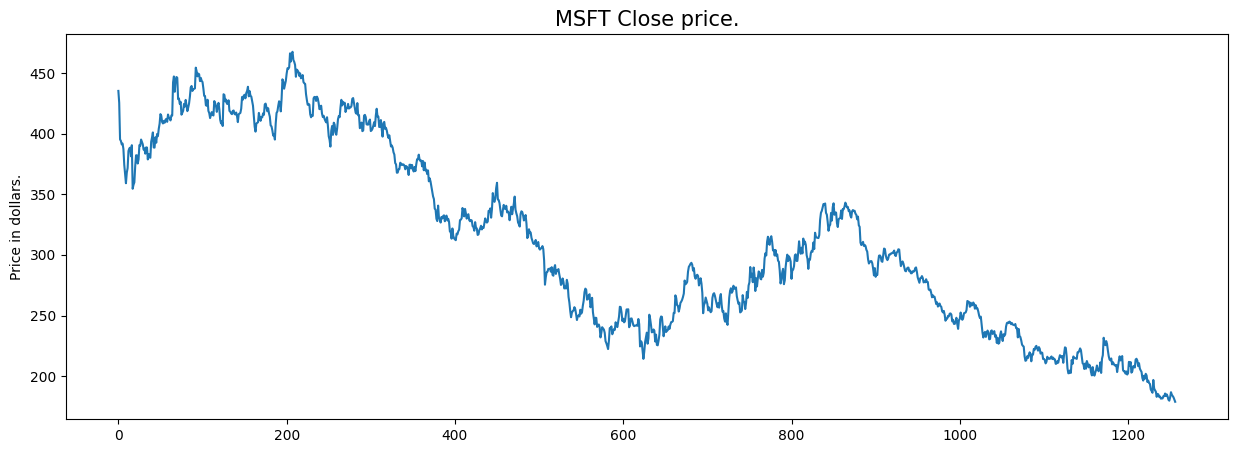

In [158]:
plt.figure(figsize=(15,5))
plt.plot(df['Close'])
plt.title('MSFT Close price.', fontsize=15)
plt.ylabel('Price in dollars.')
plt.show()

In [159]:
df.head()

,Date,Close,Open,High,Low,Volume
0,5/2/2025,435.28,431.74,439.44,429.99,30757430
1,5/1/2025,425.40,431.11,436.99,424.90,58938100
2,4/30/2025,395.26,390.30,396.66,384.44,36461080
3,4/29/2025,394.04,391.30,395.10,390.38,14973980
4,4/28/2025,391.16,391.96,392.74,386.64,16579430


In [160]:
df[df['Close'] == df['Close']].shape

(1257, 6)

In [161]:
df = df.drop(['Close'], axis=1)

In [162]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Volume    0
dtype: int64

In [165]:
parameters = ['Open','High','Low','Close','Volume']

In [ ]:
df.columns = df.columns.str.strip()  
print(df.columns.tolist())           

['Date', 'Open', 'High', 'Low', 'Volume']


In [171]:
print(df.columns.tolist())


['date', 'close', 'open', 'high', 'low', 'volume']


In [ ]:
df = pd.read_csv(r'C:\Users\jolla\OneDrive\Documents\python class\MSFT5YRHISTORICAL.csv')


df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()  

print(df.columns.tolist())  


['date', 'close', 'open', 'high', 'low', 'volume']


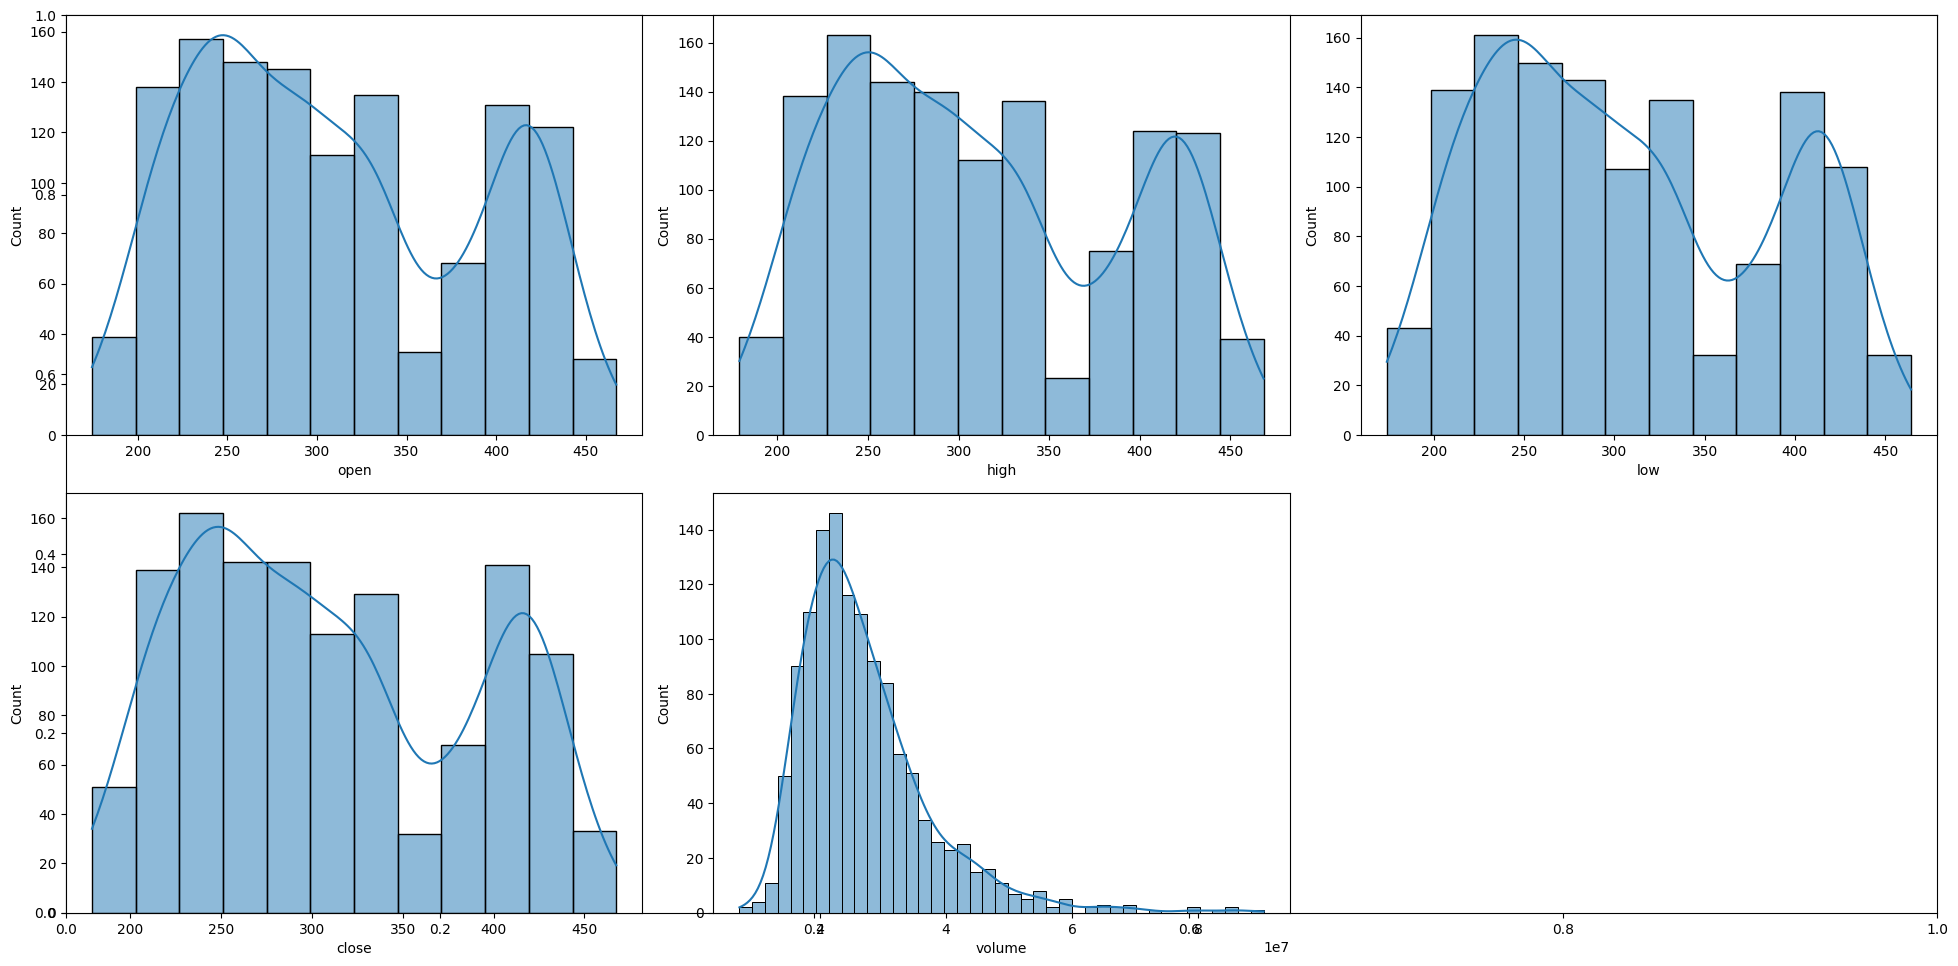

In [172]:
import seaborn as sb
import matplotlib.pyplot as plt

# Clean column names
df.columns = df.columns.str.strip()

# Define correct column names based on actual data
parameters = ['open','high','low','close','volume']  # <- adjust if needed

plt.subplots(figsize=(20, 10))
for i, col in enumerate(parameters):
    plt.subplot(2, 3, i + 1)
    sb.histplot(df[col], kde=True)
plt.tight_layout()
plt.show()


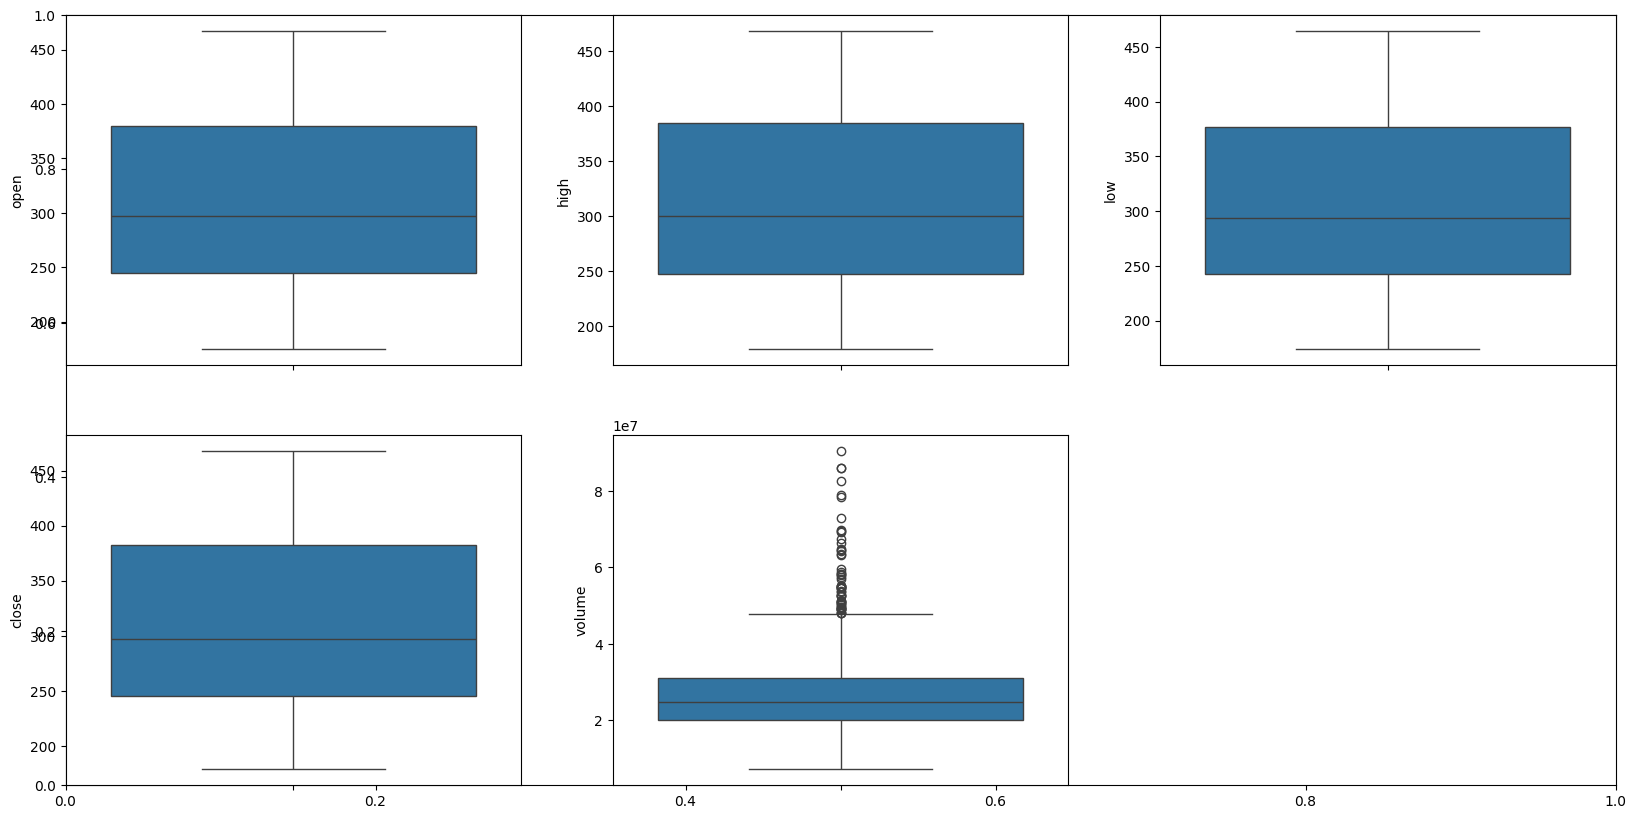

In [174]:
plt.subplots(figsize=(20,10))
for i, col in enumerate(parameters):
  plt.subplot(2,3,i+1)
  sb.boxplot(df[col])
plt.show()

In [176]:
splitted = df['date'].str.split('/', expand=True)

df['day'] = splitted[1].astype('int')
df['month'] = splitted[0].astype('int')
df['year'] = splitted[2].astype('int')

df.head()

,date,close,open,high,low,volume,day,month,year
0,5/2/2025,435.28,431.74,439.44,429.99,30757430,2,5,2025
1,5/1/2025,425.40,431.11,436.99,424.90,58938100,1,5,2025
2,4/30/2025,395.26,390.30,396.66,384.44,36461080,30,4,2025
3,4/29/2025,394.04,391.30,395.10,390.38,14973980,29,4,2025
4,4/28/2025,391.16,391.96,392.74,386.64,16579430,28,4,2025


In [177]:
df['is_quarter_end'] = np.where(df['month']%3==0,1,0)
df.head()

,date,close,open,high,low,volume,day,month,year,is_quarter_end
0,5/2/2025,435.28,431.74,439.44,429.99,30757430,2,5,2025,0
1,5/1/2025,425.40,431.11,436.99,424.90,58938100,1,5,2025,0
2,4/30/2025,395.26,390.30,396.66,384.44,36461080,30,4,2025,0
3,4/29/2025,394.04,391.30,395.10,390.38,14973980,29,4,2025,0
4,4/28/2025,391.16,391.96,392.74,386.64,16579430,28,4,2025,0


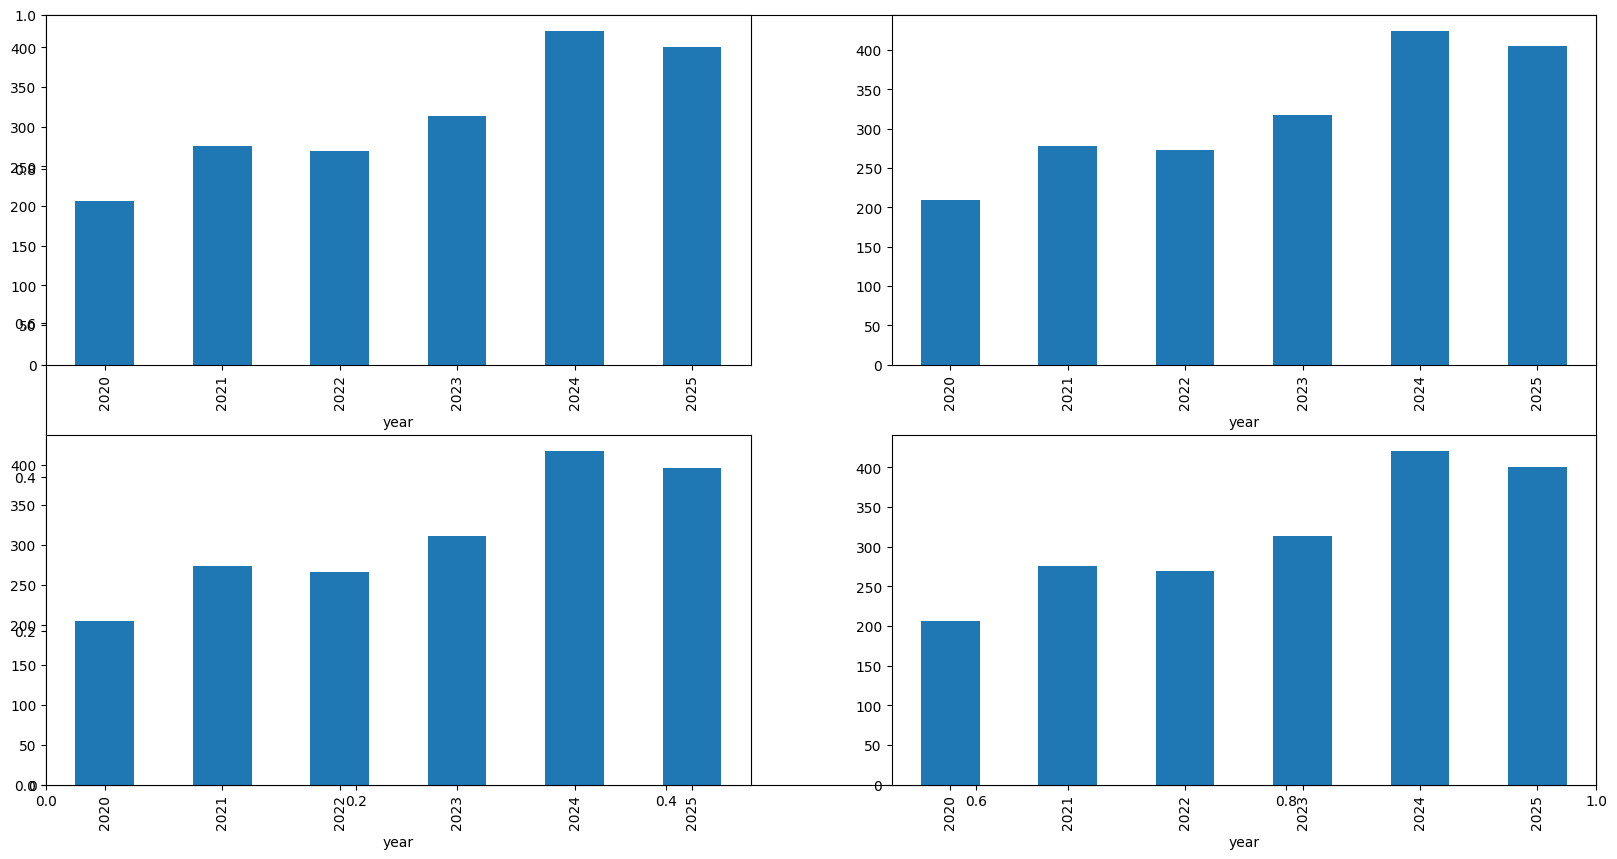

In [180]:
data_grouped = df.drop('date', axis=1).groupby('year').mean()
plt.subplots(figsize=(20,10))

for i, col in enumerate(['open', 'high', 'low', 'close']):
  plt.subplot(2,2,i+1)
  data_grouped[col].plot.bar()
plt.show()

In [182]:
df.drop('date', axis=1).groupby('is_quarter_end').mean()

,close,open,high,low,volume,day,month,year
is_quarter_end,,,,,,,,
0,311.296279,311.219076,314.291429,308.024982,2.720548e+07,15.684274,6.098439,2022.388956
1,307.342571,307.196792,310.173538,304.166910,2.671046e+07,15.752358,7.450472,2022.209906


In [183]:
df['open-close']  = df['open'] - df['close']
df['low-high']  = df['low'] - df['high']
df['target'] = np.where(df['close'].shift(-1) > df['close'], 1, 0)

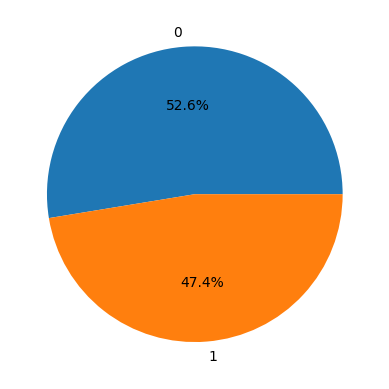

In [184]:
plt.pie(df['target'].value_counts().values, 
        labels=[0, 1], autopct='%1.1f%%')
plt.show()

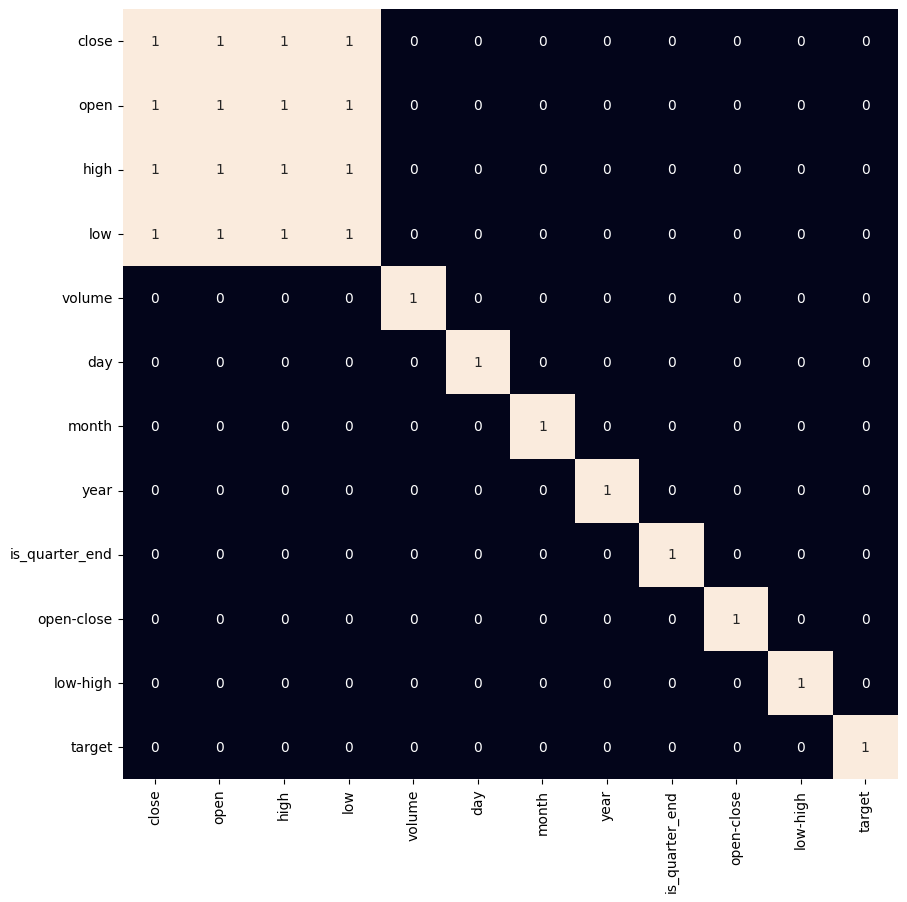

In [186]:
plt.figure(figsize=(10, 10)) 

# As our concern is with the highly 
# correlated features only so, we will visualize 
# our heatmap as per that criteria only. 
sb.heatmap(df.drop('date', axis=1).corr() > 0.9, annot=True, cbar=False)
plt.show()

# This code is modified by Susobhan Akhuli

In [188]:
parameters = df[['open-close', 'low-high', 'is_quarter_end']]
target = df['target']

scaler = StandardScaler()
features = scaler.fit_transform(parameters)

X_train, X_valid, Y_train, Y_valid = train_test_split(
    features, target, test_size=0.1, random_state=2022)
print(X_train.shape, X_valid.shape)

(1131, 3) (126, 3)


In [189]:
models = [LogisticRegression(), SVC(
  kernel='poly', probability=True), XGBClassifier()]

for i in range(3):
  models[i].fit(X_train, Y_train)

  print(f'{models[i]} : ')
  print('Training Accuracy : ', metrics.roc_auc_score(
    Y_train, models[i].predict_proba(X_train)[:,1]))
  print('Validation Accuracy : ', metrics.roc_auc_score(
    Y_valid, models[i].predict_proba(X_valid)[:,1]))
  print()

LogisticRegression() : 
Training Accuracy :  0.9001968109110966
Validation Accuracy :  0.8911772184083397

SVC(kernel='poly', probability=True) : 
Training Accuracy :  0.893537206037206
Validation Accuracy :  0.8785914060513603

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Trainin

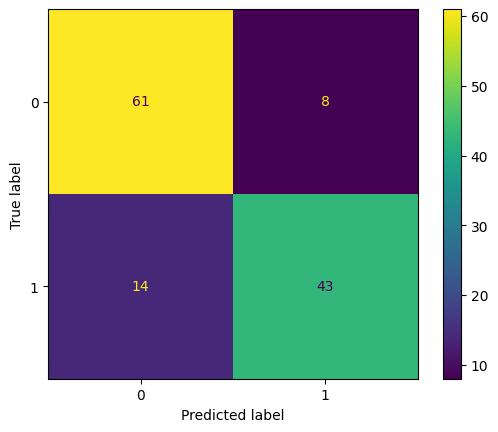

In [191]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(models[0], X_valid, Y_valid)
plt.show()